In [2]:
import pandas as pd
import numpy as np

In [3]:
df_wine = pd.read_csv(
    'https://archive.ics.uci.edu/ml/'
    'machine-learning-databases/wine/wine.data',
    header=None
)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', \
                    'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', \
                        'Proanthocyanins','Color intensity', 'Hue','OD280/OD315 of diluted wines', \
                        'Proline']

In [4]:
print(df_wine.head())

   Class label  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0            1    14.23        1.71  2.43               15.6        127   
1            1    13.20        1.78  2.14               11.2        100   
2            1    13.16        2.36  2.67               18.6        101   
3            1    14.37        1.95  2.50               16.8        113   
4            1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                          3.92  

In [5]:
print(df_wine.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class label                   178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

#### Partition the dataset

In [6]:
from sklearn.model_selection import train_test_split
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

#### Feature scaling

In [7]:
# min-max scaler: x_norm = (x-x_min)(x_max-x_min) (0-1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [8]:
# standardization: x_std = (x-mu)/sigma
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [9]:
for i in range(10):
    print(X_train_norm[i,0:2], X_train_std[i,0:2])

[0.89784946 0.24643585] [ 1.75724998 -0.42418296]
[0.46774194 0.54786151] [-0.22691937  0.87476675]
[0.57526882 0.90631365] [0.26912297 2.4194637 ]
[0.45430108 0.20570265] [-0.28892466 -0.5997167 ]
[0.57258065 0.3299389 ] [ 0.25672191 -0.06433878]
[0.68548387 0.37474542] [0.77756636 0.12874834]
[0.44892473 0.63747454] [-0.31372678  1.26094099]
[0.68010753 0.20162933] [ 0.75276425 -0.61727007]
[0.60483871 0.18329939] [ 0.40553461 -0.69626026]
[0.68548387 0.18737271] [ 0.77756636 -0.67870689]


#### Selecting meaningful features via l1

In [16]:
np.unique(y_train)

array([1, 2, 3])

/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


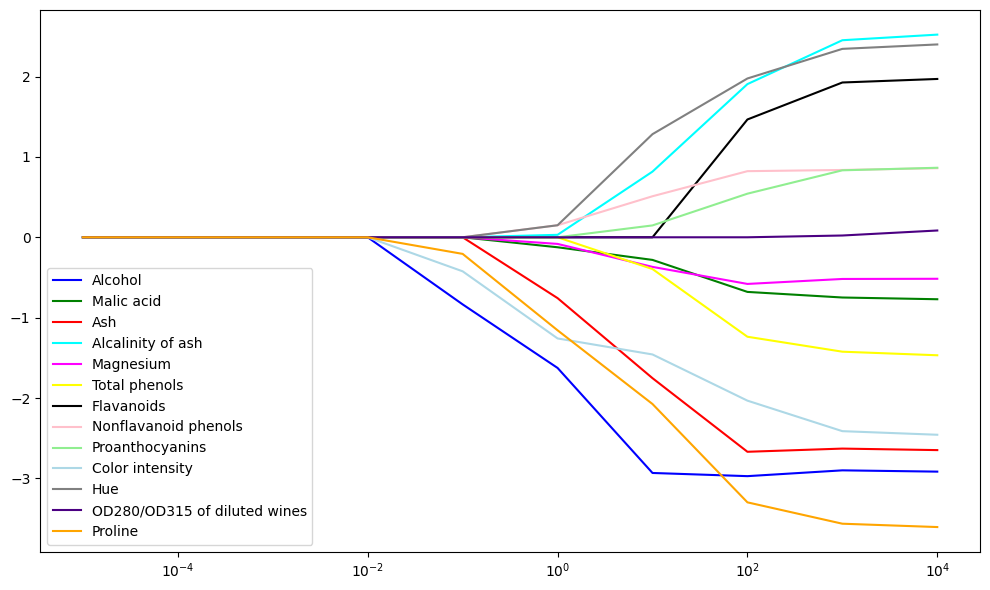

In [ ]:
# l2: shrink weights
# l1: shrink weights and remove weights (sparse solution) - prove by GD: l2: w(1-eta*lambda)**t, else l1: w +/- eta*lambda -> w - cumulative(eta*lambda) = 0
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'red', 'cyan','magenta', 'yellow', 'black', \
           'pink', 'lightgreen', 'lightblue','gray', 'indigo', 'orange']

weights, c_values = [], []

for c in np.arange(-5,5):
    model = LogisticRegression(C=10.**c, l1_ratio=1, solver='saga', random_state=1, \
                               max_iter=2000, )
    c_values.append(10.**c)
    model.fit(X_train_std, y_train)
    weights.append(model.coef_[1])

weights = np.array(weights)

plt.figure(figsize=(10,6))
for idx, color in enumerate(colors):
    plt.plot(c_values, weights[:,idx], color=color, label=df_wine.columns[idx+1])

plt.xscale('log')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


##### The images so that if we have strong regulartized value, then, most of the weights are around 0